# Introduction to Python Project : FoodHub Data Analysis

### Problem Statement

FoodHub, a food aggregator platform, connects customers with diverse restaurants. Our goal is to analyze customer order data to identify key trends, enabling FoodHub to enhance customer satisfaction and refine its operational strategies.

### Data Dictionary

**order_id**: Unique ID of the order

**customer_id**: ID of the customer who ordered the food

**restaurant_name**: Name of the restaurant

**cuisine_type**: Cuisine ordered by the customer

**cost_of_the_order**: Cost of the order

**day_of_the_week**: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)

**rating**: Rating given by the customer out of 5

**food_preparation_time**: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.

**delivery_time**: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [65]:
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q

In [66]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Command to tell Python to actually display the graphs
%matplotlib inline
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Understanding the structure of the data

In [67]:
df = pd.read_csv('/content/foodhub_order.csv')

In [68]:
display(df.head())

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [69]:
display(df.tail())

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


In [70]:
display(df.sample(5))

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
836,1476735,369272,Blue Ribbon Sushi Bar & Grill,Japanese,11.69,Weekday,5,21,28
581,1477321,89844,Five Guys Burgers and Fries,American,12.08,Weekend,Not given,20,18
1462,1476932,301032,Mission Cantina,Mexican,29.15,Weekend,Not given,31,26
1508,1477718,42755,Blue Ribbon Sushi,Japanese,16.11,Weekend,5,22,26
456,1478046,53289,The Loop,Japanese,31.38,Weekend,4,26,24


In [71]:
display(df['order_id'].nunique())
display(df['customer_id'].nunique())
display(df['restaurant_name'].nunique())
display(df['cuisine_type'].nunique())
display(df['day_of_the_week'].nunique())
display(df['rating'].unique())

1898

1200

178

14

2

array(['Not given', '5', '3', '4'], dtype=object)

# Observations

Based on the data extracted, we can make the following observations:

*   `order_id` is a unique identifier for each transaction.
*   Few customers have placed orders multiple number of times through the application.
*   The platform features 178 distinct restaurants offering 14 different cuisine types.
*   Order days are categorized into two groups: weekdays and weekends.
*  Rating column will either have numerical or 'Not given' as value.



### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [72]:
display(f"Number of rows: {df.shape[0]}")
display(f"Number of columns: {df.shape[1]}")

'Number of rows: 1898'

'Number of columns: 9'

## Answer:

*   There is total 1898 rows and 9 columns



### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [73]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


None

## Answer

*   The dataset consists of 9 columns, with 4 columns as integers, 4 as objects, and 1 as a float data type.
*   `order_id`, `customer_id`, `food_preparation_time`, and `delivery_time` are integer data types.
*   `restaurant_name`, `cuisine_type`, `day_of_the_week`, and `rating` are object data types.
*   `cost_of_the_order` is a float data type.

#### Observations:

*   All columns are populated, indicating no missing values in the dataset.
*   `cuisine_type` and `day_of_the_week` are categorical features suitable for frequency analysis or grouping.
*   The `rating` column, while currently an `object` type, contains categorical values (including 'Not given') which should be handled appropriately for numerical analysis.
*   `order_id` and `customer_id` are identifiers and, despite being numerical, are not suitable for direct statistical aggregation like mean or standard deviation.
*   `cost_of_the_order`, `food_preparation_time`, and `delivery_time` are numerical variables that can be analyzed for distributions, central tendencies, and variability.
*   The `restaurant_name` column can be valuable when combined with other metrics like order volume, ratings, or cuisine types to derive business insights.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

## Answer:

While no explicit null values were initially found in the data, the 'rating' column contained 'Not given' values, which have been treated as missing values.

In [74]:
df['rating'].replace('Not given', np.nan, inplace=True)
df['rating'] = df['rating'].astype(float)
display(df.isnull().sum());

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,736
food_preparation_time,0
delivery_time,0


#### Observations:

*   The 'Not given' values in the 'rating' column have been successfully replaced with `NaN` (Not a Number), indicating orders without an associated rating.
*   A total of 736 orders were found to have no ratings, which is now represented by `NaN` values.
*   We have also updated the rating column as float type.

In [75]:
df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 133.6+ KB


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [76]:
pd.options.display.float_format = '{:.2f}'.format
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
order_id,1898.00,1477495.50,548.05,1476547.00,1477021.25,1477495.50,1477969.75,1478444.00
customer_id,1898.00,171168.48,113698.14,1311.00,77787.75,128600.00,270525.00,405334.00
cost_of_the_order,1898.00,16.50,7.48,4.47,12.08,14.14,22.30,35.41
rating,1162.00,4.34,0.74,3.00,4.00,5.00,5.00,5.00
food_preparation_time,1898.00,27.37,4.63,20.00,23.00,27.00,31.00,35.00
delivery_time,1898.00,24.16,4.97,15.00,20.00,25.00,28.00,33.00


## Answer:

*   As per the statistical summary of data above - Minimum food preparation time is 20 mins, average is 27.37 min and maximum it is taking 35 minutes.



#Observation

The statistical summary includes customer_id and order_id, which are identifiers. While they appear as numerical types, their inclusion in statistical measures like mean or standard deviation can be misleading, as these metrics are not meaningful for unique identifiers. Therefore, converting their data types to 'category' is a more appropriate representation.

In [77]:
df['order_id'] = df['order_id'].astype('category')
df['customer_id'] = df['customer_id'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   order_id               1898 non-null   category
 1   customer_id            1898 non-null   category
 2   restaurant_name        1898 non-null   object  
 3   cuisine_type           1898 non-null   object  
 4   cost_of_the_order      1898 non-null   float64 
 5   day_of_the_week        1898 non-null   object  
 6   rating                 1162 non-null   float64 
 7   food_preparation_time  1898 non-null   int64   
 8   delivery_time          1898 non-null   int64   
dtypes: category(2), float64(2), int64(2), object(3)
memory usage: 232.4+ KB


In [78]:
pd.options.display.float_format = '{:.2f}'.format
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
cost_of_the_order,1898.00,16.50,7.48,4.47,12.08,14.14,22.30,35.41
rating,1162.00,4.34,0.74,3.00,4.00,5.00,5.00,5.00
food_preparation_time,1898.00,27.37,4.63,20.00,23.00,27.00,31.00,35.00
delivery_time,1898.00,24.16,4.97,15.00,20.00,25.00,28.00,33.00


#### Observations:

*   Standard deviation for both food preparation time and delivery time is around ~5, which shows that we can further analyse the reason behind both of them.

*   The cost of 25% of the orders ranges from 12.00 (25th percentile)  to 14.14 (50th percentile).

*   Rating has less standard deviation than 1, which shows ratings are lieing under very tight range.

### Action Item:



1.   Lets analyse the price of food with respect to cuisine type and restaurant name to see any pattern between the price of food and other variable
2.   Lets analyse food prepartion time more closely to figure out if the time taken has any impact from cuisine type or restaurant.

### **Question 5:** How many orders are not rated? [1 mark]

In [79]:
pd.options.display.float_format = '{:.2f}'.format
print(df['rating'].isnull().sum())

736


## Answer:

There is 736 orders that are not rated.

#### Observations:

check if there is any pattern in missing rating, with respect tor restaurant, week days or user.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

## Prior Observation:

For univariate and other analyses, we will need to plot similar graphs for different variables. Therefore, it is advisable to create functions to streamline this process.

In [80]:
def plot_histogram(
    dataframe, column_name, graph_alias, hue_value=None):
  plt.title('Histogram:'+ graph_alias)
  sns.histplot(data=dataframe, x=column_name, hue=hue_value, kde = True);

def plot_boxplot(dataframe, column_name, graph_alias):
    plt.title('Boxplot:' + graph_alias)
    sns.boxplot(data=dataframe, x=column_name)


def count_boxplot(dataframe, column_name, graph_alias, hue_value=None):
    plt.title('Countplot:' + graph_alias)
    sns.boxplot(data=dataframe, x=column_name, hue=hue_value)


### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

## Prior Observation:

There are 4 numerical variables. Plotting individual graphs for all of them might consume significant space; therefore, we will utilize subplotting to display them efficiently.

<Figure size 640x480 with 0 Axes>

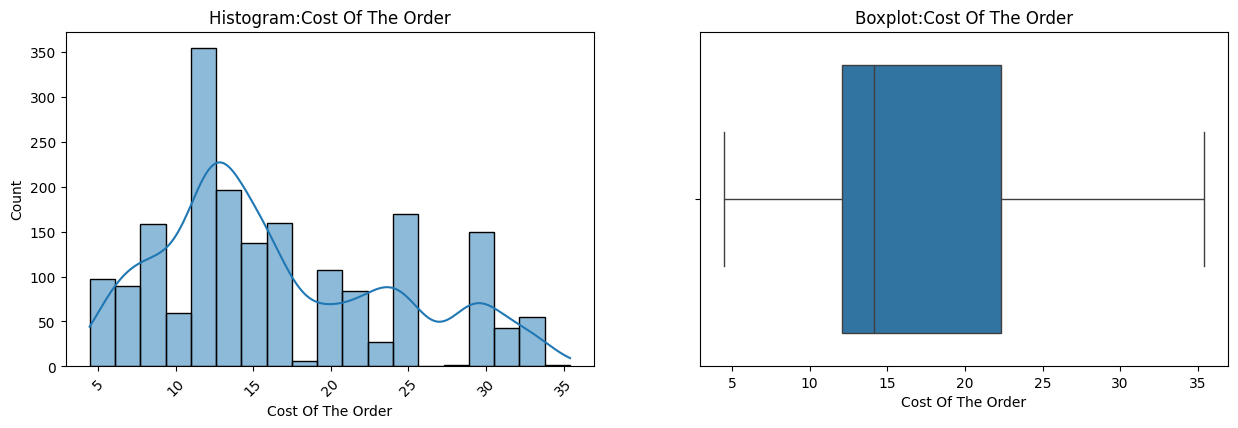

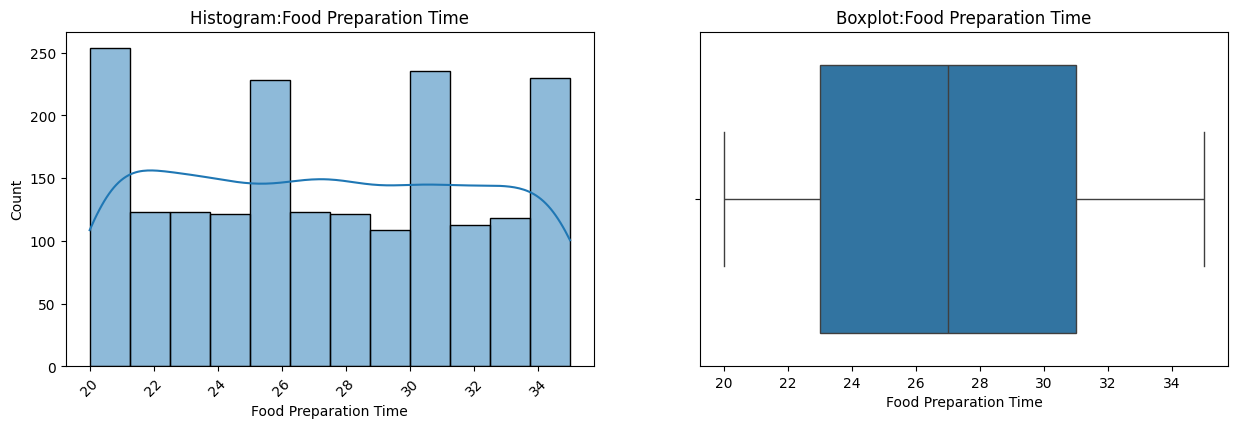

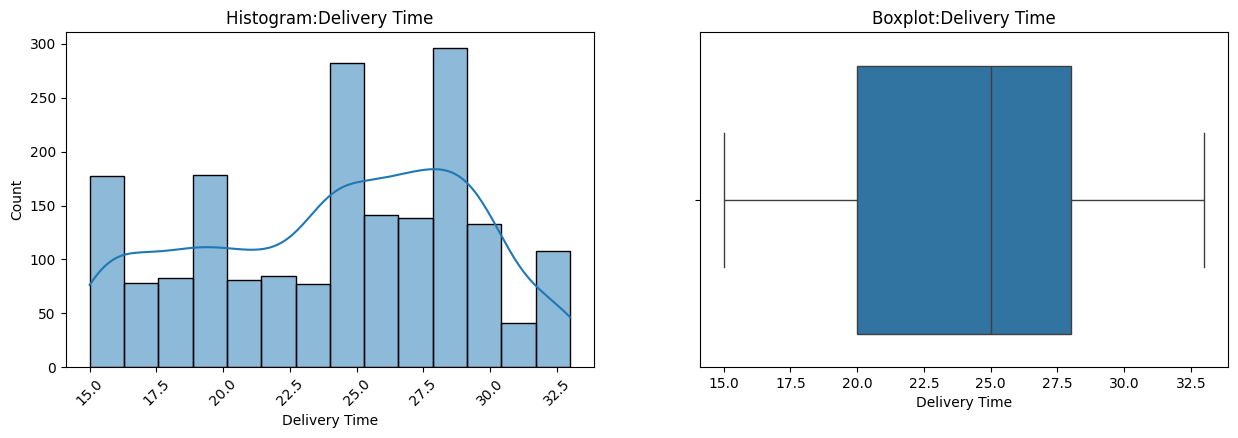

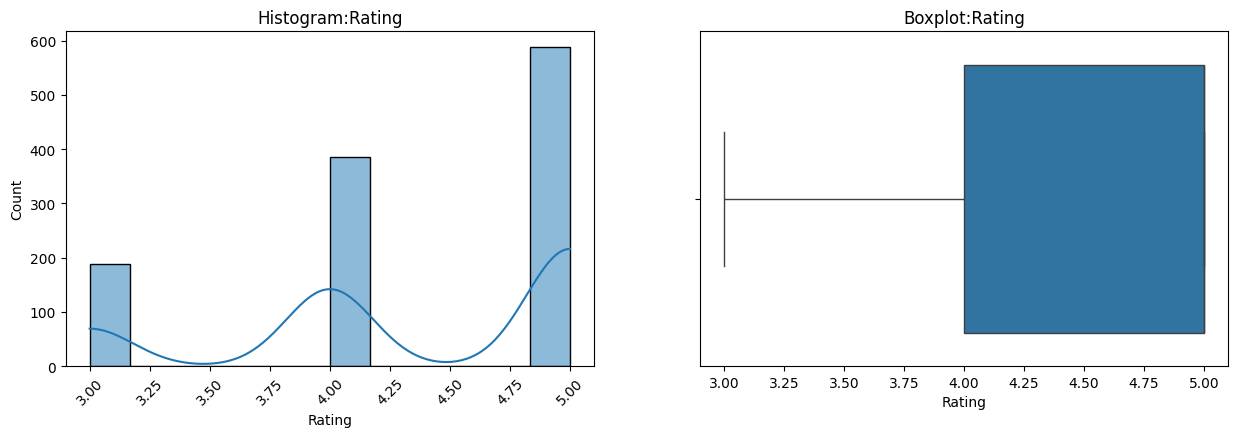

In [81]:
def subplot_graphs(column_names):
  for i, col in enumerate(column_names):
    plt.figure(figsize=(15, 20))
    plt.subplot(len(column_names), 2, 2 * i + 1)
    plot_histogram(df, col, col.replace('_', ' ').title());
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel('Count')
    plt.xticks(rotation=45)

    # Boxplot subplot
    plt.subplot(len(column_names), 2, 2 * i + 2)
    plot_boxplot(df, col, col.replace('_', ' ').title());
    plt.xlabel(col.replace('_', ' ').title())

plt.tight_layout();
plt.show();

subplot_graphs(['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']);

##Observation:

*   In the above sub-plot, **rating graph** isn't making much sense. We shall go for count plot for this.
*   **For Cost Histogram and boxplot we can conclude that**,


1.   there is a huge spikes of count of order between 10 to 15 dollars, and the graph is rightly skewed.
2.   Median of Histogram resides before 15 only, which says half of the order cost less than 15 dollars



*   **Food preparation time** shows balanced data, there are 4 high bins which are almost same in height and then other bins which are almost same in their group.
*   In **Delivery time** a spike can be seen in ~25 min to ~29 min, which shows most of the order is delivered under this time.

## Action Item:



3.   Analyse the rating data using count plot keeping cuisine as hue.
2.   Analyse the delivery time keeping day of the week as hue.










### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [82]:
display(df['restaurant_name'].value_counts().head())

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


In [83]:
restaurants = ['Blue Ribbon Fried Chicken', 'Shake Shack', 'The Meatball Shop', 'Blue Ribbon Sushi', 'Parm']


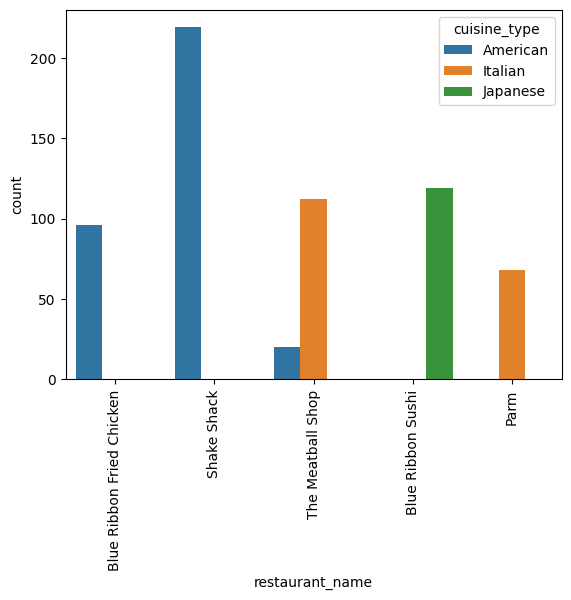

In [84]:
top_restaurants_df = df[df['restaurant_name'].isin(restaurants)]
sns.countplot(data=top_restaurants_df, x='restaurant_name', order=restaurants, hue='cuisine_type');
plt.xticks(rotation=90);

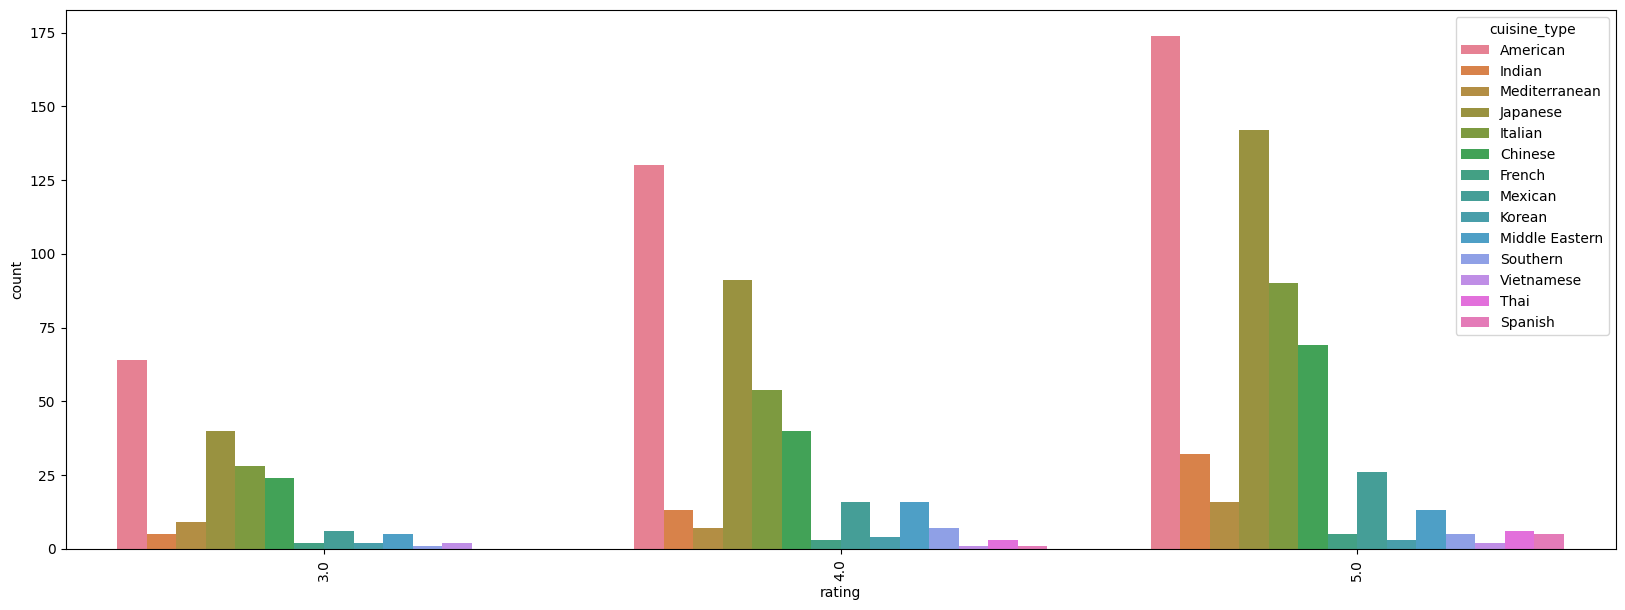

In [85]:
plt.figure(figsize=(20,7))
sns.countplot(data=df, x='rating', hue='cuisine_type');
plt.xticks(rotation=90);

## Answer:

These are the five top restaurants:  Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, Parm

#### Observations:

*   The last cuisine type plots shows that, top rated cuisine types are - American, Japanese, Italian, Chinese. Mexican and Indian.
*   Top 5 restaurants hold a large number of orders and the first and fifth restaurant itself has a huge order gap.

*   There are total 1898 order from which 634 orders are done from the 5 restaurant which is ~35% of the order.
*   As shown in both the last graph, sale and ratings for these cuisines American, Japanese, Italian are way higher.






### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

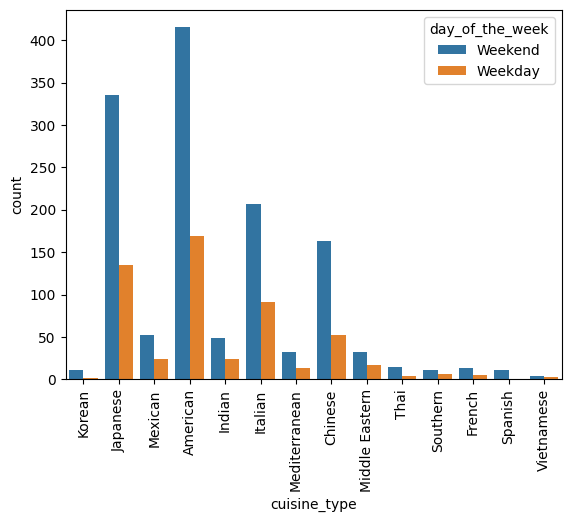

In [86]:
sns.countplot(data=df, x='cuisine_type', hue='day_of_the_week');
plt.xticks(rotation=90);

## Answer:

American, Japanese, Italian, Chinese. Mexican and Indian are most popular in the same order.

#### Observations:

The cuisine type data trend seems to be same as plotted above keeping all the cases, whether rating, days, restaurants.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [87]:
df_cost_20 = df[df['cost_of_the_order'] > 20]
display(df_cost_20.shape[0]/df.shape[0]*100)

29.24130663856691

#### Observations:

*   ~29% of order are more than 20 dollars.



### **Question 10**: What is the mean order delivery time? [1 mark]

In [88]:
print(df['delivery_time'].mean());

24.161749209694417


#### Observations:



*   Mean Order delivery time is ~24 mins.




### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [89]:
df_customers = df['customer_id'].value_counts().head(3)
display(df_customers)

,count
customer_id,
52832,13
47440,10
83287,9


## Observation:



*   Customer Id 52832, 47440, 83287	are top 2 most frequent customers.



### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


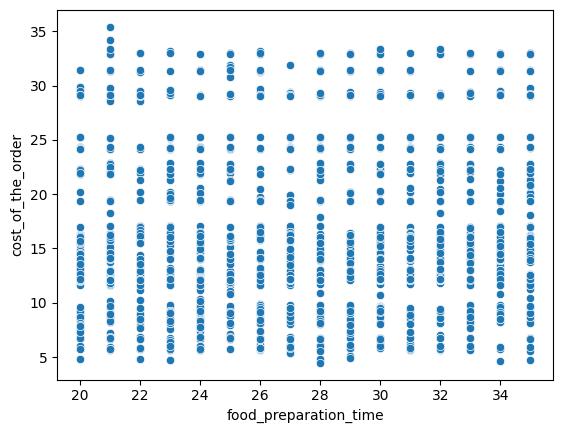

In [90]:
sns.scatterplot(data=df, x='food_preparation_time', y='cost_of_the_order');

The above scatterplot is making no sense, lets look into heatmap to see the correlated variables.

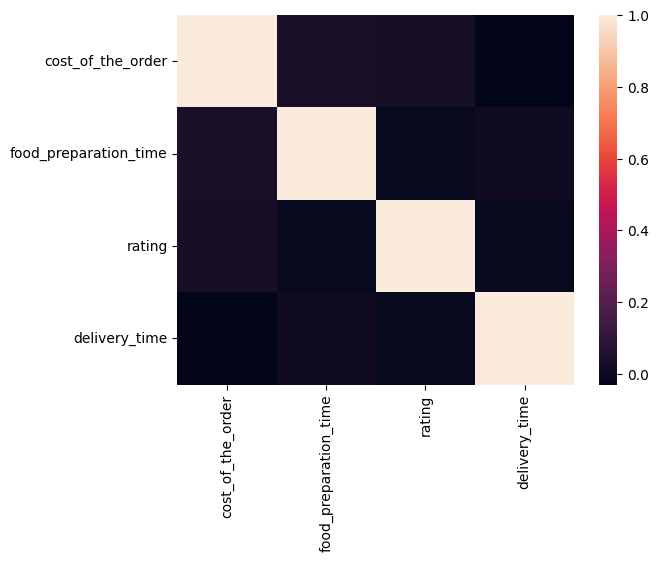

In [91]:
sns.heatmap(data=df[['cost_of_the_order','food_preparation_time','rating','delivery_time']].corr());

The above heatmap clearly shows that there is no correlation between all the numerical variables. So, lets explore the relation between numerical and categorical variable.

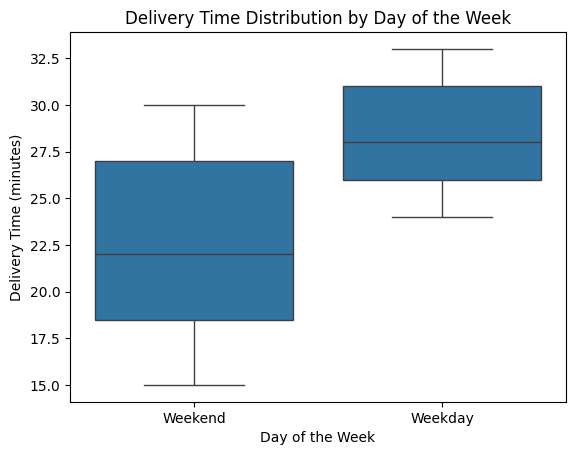

In [92]:
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time')
plt.title('Delivery Time Distribution by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time (minutes)')
plt.show()

#### Observations:
*   The above graph clearly shows that delivery time on weekend is comparatively less that weekdays.


#### Cost of the Order by Cuisine Type

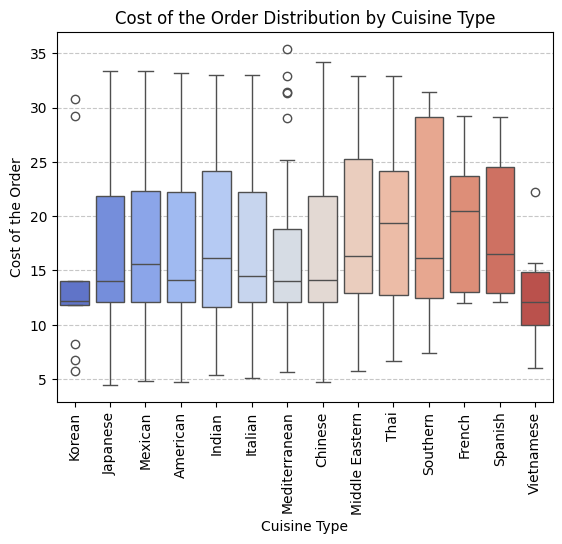

In [93]:

sns.boxplot(data=df, x='cuisine_type', y='cost_of_the_order', palette='coolwarm')
plt.title('Cost of the Order Distribution by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Cost of the Order')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Observations:



*   We concluded above that American, Japanese, Italian and Chinese are most popular cuisine, and from the above graph we can see median for all these cuisine lies at same range, which is below 15 dollar.
*   Some cuisines like Italian and American show a wider spread in order costs, indicating a larger range of prices for dishes within those categories.
*   Outliers are visible for several cuisine types, suggesting some particularly expensive orders within those categories.

#### Food Preparation Time by Cuisine Type

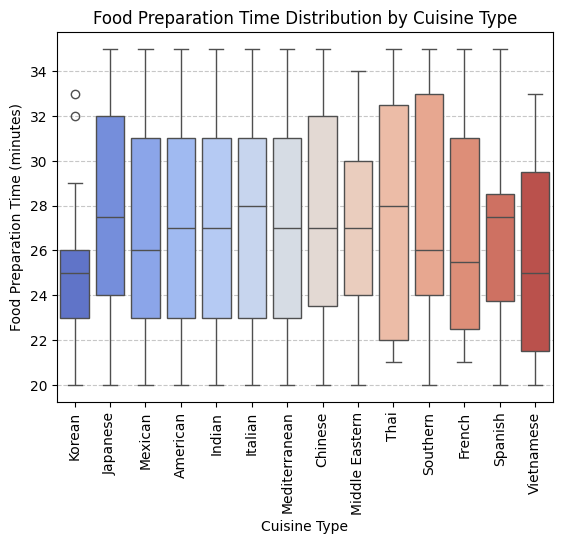

In [94]:
sns.boxplot(data=df, x='cuisine_type', y='food_preparation_time', palette='coolwarm')
plt.title('Food Preparation Time Distribution by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Food Preparation Time (minutes)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Observations:
*   Food preparation times are relatively consistent across most cuisine types, with medians hovering around 26-28 minutes.
*   Some cuisines might show slightly different distributions or a wider range of preparation times, indicating potential variations in complexity or restaurant efficiency for those types.
*   Most cuisines have a similar interquartile range, suggesting that the majority of orders are prepared within a narrow time window.

#### Average Rating by Cuisine Type

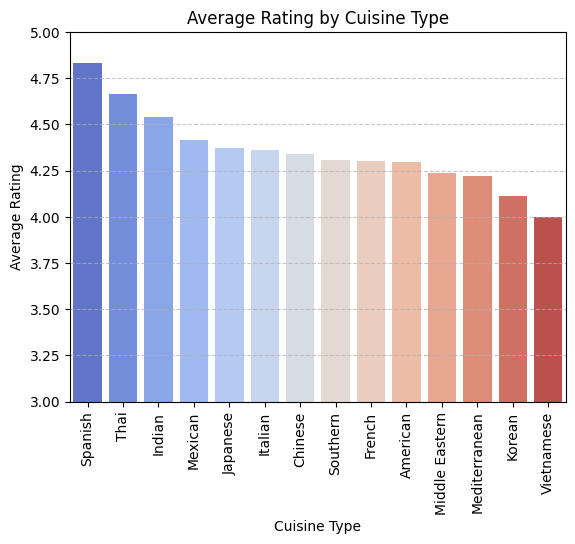

In [95]:
sns.barplot(data=df.groupby('cuisine_type')['rating'].mean().reset_index().sort_values(by='rating', ascending=False), x='cuisine_type', y='rating', palette='coolwarm')
plt.title('Average Rating by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(3, 5)
plt.show()

#### Observations:
*   Most cuisine types have average ratings above 4, indicating general customer satisfaction across the platform.
*   There are slight variations, with some cuisines receiving marginally higher average ratings than others.
*   This plot helps identify which cuisine types are consistently performing well in terms of customer satisfaction, which can be valuable for promotional strategies.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [96]:
df_rating = df.groupby('restaurant_name').agg({'rating':'mean', 'customer_id':'count'})
df_rating.head()

,rating,customer_id
restaurant_name,,
'wichcraft,5.00,1
12 Chairs,4.50,4
5 Napkin Burger,4.00,5
67 Burger,5.00,1
Alidoro,NaN,1


In [97]:
df_rating[(df_rating['customer_id'] > 50) & (df_rating['rating'] > 4)].sort_values(by='customer_id', ascending=False)

,rating,customer_id
restaurant_name,,
Shake Shack,4.28,219
The Meatball Shop,4.51,132
Blue Ribbon Sushi,4.22,119
Blue Ribbon Fried Chicken,4.33,96
Parm,4.13,68
RedFarm Broadway,4.24,59
RedFarm Hudson,4.18,55


#### Observations:



*   There are 7 restaurants listed above which has 50+ rating count and average rating is more than 4.




### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [98]:
gross_income = (df[df['cost_of_the_order'] > 20]['cost_of_the_order'] * 1.25).sum() + \
(df[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] < 20)]['cost_of_the_order'] * 1.15).sum() + \
(df[df['cost_of_the_order'] < 5]['cost_of_the_order'] * 1).sum()

gross_income_by_restaurant = df['cost_of_the_order'].sum()

net_income = gross_income - gross_income_by_restaurant

print(f"Gross Income: ${gross_income:.2f}")
print(f"Net Income: ${net_income:.2f}")

Gross Income: $37481.12
Net Income: $6166.30


#### Observations:

*   We've kept the logic in a way, that we are calculating gross income of company and then gross income of restaurant. Once we have both, we are subtracting gross income of restaurant by gross income of company.
*   Net Income of Company is 6166.30 dollar.






### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [99]:
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
df.sample()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_time
630,1476710,65009,Blue Ribbon Sushi Izakaya,Japanese,8.93,Weekend,5.00,28,18,46




*   We've added one more column `total_time` in the dataframe. this will include the summation of `food_preparation_time` and `delivery_time`.





In [100]:
order_time_percentage_above_60 = (df[df['total_time'] > 60].shape[0]/df.shape[0])*100

print(f"Order that take more than 60 minutes to deliver: {order_time_percentage_above_60:.2f}%")


Order that take more than 60 minutes to deliver: 10.54%


#### Observations:

There are 10.54% orders that take more than 60 minutes to deliver.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [101]:
df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.34
Weekend,22.47


#### Observations:



*   We can clearly see that the average delivery time take on weekend is ~6 minutes less than on weekdays.




### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

*   **Delivery Time Variation:** Weekday deliveries consistently take longer on average, indicating potential operational differences or higher traffic during weekdays.
*   **Order Volume Distribution:** A significant portion of orders are placed on weekends, suggesting higher demand during these periods.
*   **Restaurant and Cuisine Dominance:** The top 5 restaurants, primarily offering American, Italian, and Japanese cuisines, account for a substantial share of total orders i.e. ~35%, highlighting their popularity.
*   **Customer Preferences:** American, Japanese, Italian, and Chinese cuisines are the most frequently ordered, aligning with the popularity of the top restaurants.
*   **Rating vs. Popularity:** While American, Japanese, and Italian cuisines are popular in terms of order volume, Spanish, Thai, Indian, and Mexican cuisines exhibit higher average customer ratings, suggesting potential for growth if promoted effectively.
*   **Cost of Orders:** A large concentration of orders fall within the 10-15 dollar range, with the median cost below 15 dollar. Approximately 29%  of orders exceed $20.
*   **Food Preparation Consistency:** Food preparation times are generally consistent across various cuisine types, with most orders being prepared within a similar time frame (median around 26-28 minutes).
*   **Correlation of Numerical Variables:** There is no significant correlation observed between numerical variables such as cost of order, food preparation time, delivery time, and rating.
*   **Long Delivery Times:** About 10.54% of all orders take more than 60 minutes for preparation and delivery combined, which could be a point of concern for customer satisfaction.

### Recommendations:

Based on the analysis, here are several recommendations to help FoodHub improve its business operations and customer satisfaction:

*   **Optimize Weekday Deliveries:** Investigate the factors contributing to longer weekday delivery times (mean of ~28 minutes compared to ~22 minutes on weekends). This could involve optimizing delivery routes, increasing driver availability during peak weekday hours, or introducing incentives for faster weekday deliveries. Reducing these times can significantly improve customer experience and potentially increase repeat orders on weekdays.

*   **Leverage Top-Rated, Less Popular Cuisines:** Given that Spanish, Thai, Indian, and Mexican cuisines exhibit higher average customer ratings despite lower order volumes, FoodHub should actively promote these options. This could include featuring them prominently in marketing campaigns, offering special discounts, or creating curated lists to increase their visibility and encourage customers to try them. This strategy can diversify customer choices and capitalize on existing high satisfaction levels.

*   **Expand Reach of Popular Restaurants:** Support and encourage the top 5 most popular restaurants (Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, Parm) to expand their operational capacity or delivery zones. This could involve partnerships for satellite kitchens in underserved areas, or providing data-driven insights to help them optimize their operations, thereby increasing their total order capacity and potentially reducing delivery times.

*   **Strategic Partnerships for Popular Cuisines:** Continuously seek to onboard new restaurants that offer American, Japanese, Italian, and Chinese cuisines. These cuisine types consistently show high demand and popularity. Expanding the variety and availability within these categories can help capture a larger market share and maintain customer interest.

*   **Target Weekday Office and Group Orders:** Develop tailored promotional offers or corporate meal plans specifically for weekday orders, especially targeting businesses and offices. This strategy can help balance the order volume, which is currently skewed towards weekends, and tap into a potentially large market segment during off-peak days.

*   **Address and Resolve Long Delivery Times:** A significant 10.54% of all orders exceed 60 minutes for combined food preparation and delivery. FoodHub must identify the root causes for these extended times (e.g., specific restaurant bottlenecks, complex order types, or inefficient delivery logistics). Implementing targeted solutions will be crucial for improving customer satisfaction and retention, as long waits are a common point of friction.

*   **Enhance Customer Loyalty Programs:** Continue to recognize and reward the most frequent customers (IDs 52832, 47440, 83287). Implementing tiered loyalty programs, personalized offers, or exclusive access to new features can further strengthen their engagement and ensure their continued business.

*   **Boost Rating Engagement:** With 736 unrated orders, there's a substantial amount of untapped feedback. FoodHub should implement strategies to encourage more customers to leave ratings. This could involve simplified in-app rating prompts, small incentives for providing feedback, or post-delivery reminders. Increased ratings will provide a richer dataset for further analysis and continuous improvement.